# XGBoost Algorithm

In [1]:
from xgboost import XGBClassifier
# from xgboost import XGBRegressor

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import matplotlib.pyplot as plt
import pandas as pd

Load Dataset

In [2]:
data = load_breast_cancer()

X = data.data

y = data.target

feature_names = data.feature_names

class_names = data.target_names

print("Dataset Shape: ",X.shape)

print(feature_names)
print(feature_names.shape)

print('Class: ',class_names)

Dataset Shape:  (569, 30)
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
(30,)
Class:  ['malignant' 'benign']


Check Class Distribution

In [3]:
print(pd.Series(y).value_counts())
pd.Series(y).value_counts(normalize=True)*100

1    357
0    212
Name: count, dtype: int64


1    62.741652
0    37.258348
Name: proportion, dtype: float64

In [4]:
# First 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y, test_size=0.3, stratify=y, random_state=42
)

# Second: split temporary 50/50
# Final result = 70% train, 15% validation, 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nDataset split:")
print("Training : ",X_train.shape)
print("Validation : ",X_val.shape)
print("Test : ",X_test.shape)


Dataset split:
Training :  (398, 30)
Validation :  (85, 30)
Test :  (86, 30)


In [5]:
model = XGBClassifier(
    max_depth = 4,
    learning_rate = 0.05,
    n_estimators = 1000,
    eval_metric = 'logloss',
    n_jobs = -1,
    random_state = 42,
    subsample = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 30
)

In [6]:
model.fit(
    X_train, y_train,
    eval_set = [(X_train,y_train),(X_val,y_val)],
    verbose = True
)

[0]	validation_0-logloss:0.61897	validation_1-logloss:0.62180
[1]	validation_0-logloss:0.58164	validation_1-logloss:0.58531
[2]	validation_0-logloss:0.54712	validation_1-logloss:0.55021
[3]	validation_0-logloss:0.51687	validation_1-logloss:0.52002
[4]	validation_0-logloss:0.48814	validation_1-logloss:0.49021
[5]	validation_0-logloss:0.46238	validation_1-logloss:0.46312
[6]	validation_0-logloss:0.43838	validation_1-logloss:0.43816
[7]	validation_0-logloss:0.41554	validation_1-logloss:0.41528
[8]	validation_0-logloss:0.39467	validation_1-logloss:0.39203
[9]	validation_0-logloss:0.37525	validation_1-logloss:0.37262
[10]	validation_0-logloss:0.35691	validation_1-logloss:0.35542
[11]	validation_0-logloss:0.34025	validation_1-logloss:0.33826
[12]	validation_0-logloss:0.32444	validation_1-logloss:0.32119
[13]	validation_0-logloss:0.30954	validation_1-logloss:0.30678
[14]	validation_0-logloss:0.29594	validation_1-logloss:0.29289
[15]	validation_0-logloss:0.28296	validation_1-logloss:0.27986
[1

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impor

In [7]:
import xgboost
import sklearn

print("sklearn version ",sklearn.__version__)
print("xgboost : ",xgboost.__version__)

sklearn version  1.8.0
xgboost :  3.4.1


In [15]:
results = model.evals_result()
print(results)

{'validation_0': OrderedDict({'logloss': [0.6189731412646758, 0.5816378444433212, 0.5471178137477318, 0.5168694817091353, 0.4881445436771192, 0.4623752160737263, 0.4383790970747195, 0.4155433539619398, 0.39467082880250176, 0.3752461453179019, 0.35691201739275275, 0.34025228487786335, 0.3244412685159463, 0.3095394652992038, 0.2959374220452117, 0.2829638379228175, 0.27092019932803196, 0.25941707089019184, 0.24846388822674154, 0.23794063135756918, 0.22847084768453435, 0.2189242149417724, 0.21039423747128577, 0.2020392291734566, 0.19402086650531494, 0.1859861030500738, 0.1791600038545515, 0.17236114620937773, 0.16650351498219834, 0.16072829402795988, 0.155492423954022, 0.1498343917218285, 0.14431621871851197, 0.13961433143771473, 0.1347455793252243, 0.130444106238721, 0.12577636994833324, 0.12164763205839162, 0.11749068949015895, 0.11393311807895126, 0.11095704099902855, 0.10735358327776942, 0.10457164536805907, 0.10115877376054999, 0.09823543044864833, 0.09525566108187838, 0.0924538365335

In [16]:
print(f"Best iteration : ",{model.best_iteration})

Best iteration :  {530}


Training / Validation Curve

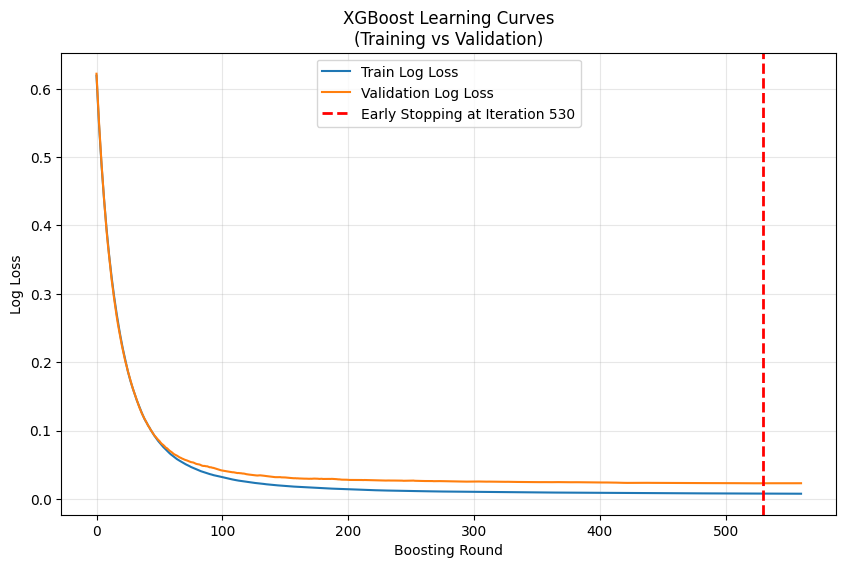

In [17]:
plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['logloss'], label='Train Log Loss')
plt.plot(results['validation_1']['logloss'],label='Validation Log Loss')

# Mark the point where early stopping kicked in

plt.axvline(
    x=model.best_iteration,
    color='red',
    linestyle = '--',
    linewidth = 2,
    label = f"Early Stopping at Iteration {model.best_iteration}"


)

plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title("XGBoost Learning Curves\n(Training vs Validation)")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [20]:
y_test_predict = model.predict(X_test)
print(classification_report(y_test,y_test_predict,target_names=class_names))

              precision    recall  f1-score   support

   malignant       0.93      0.84      0.89        32
      benign       0.91      0.96      0.94        54

    accuracy                           0.92        86
   macro avg       0.92      0.90      0.91        86
weighted avg       0.92      0.92      0.92        86



Save train model

In [21]:
model.save_model("breast_cancer_xgboost.json")

print("\nModel saved successfully.")


Model saved successfully.


Load Json file

In [22]:
loaded = XGBClassifier()
loaded.load_model("breast_cancer_xgboost.json")


Get Inference (This use train data row - this actually wrong)

In [ ]:
print(X[1])
print(y[1]) 

[2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
 7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
 5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
 2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
 2.750e-01 8.902e-02]
0


In [25]:
loaded.predict(X[[1]])

array([0])